# Experiment A — Obesity screening from serum NMR (MTBLS242)
### `ข้อมูลจากไหน → ใช้วิธีอะไร → ผลยังไง`
BDI Hackathon 2026 · PhenoInsure Tech · env `superaiss6`

> **Honest-by-design.** Real cohort, real label, held-out cross-validation. No synthetic augmentation, no training-set performance. Everything shown on the ROC figure states *where the data came from* and *how it was measured*.

---

## 1. ข้อมูลจากไหน — Data source

**MTBLS242** (MetaboLights) — a **bariatric (weight-loss) surgery cohort**. Serum $^1$H-NMR, 465 samples, 21 quantified metabolites. Patients start morbidly obese and lose weight over 12 months, so the *time point* is a natural obesity signal. We take the two extremes as a clean binary label:

| Class | Time point | n |
|---|---|---|
| **obese** (1) | `preop` (before operation) | 106 |
| **healthy** (0) | `12 months after surgery` | 71 |

Intermediate 3/6/9-month samples (mid-weight-loss, ambiguous) are excluded. **This is a real measured cohort — not simulated spectra.**

In [1]:
import csv, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, precision_recall_curve
from xgboost import XGBClassifier

DATA = '/Users/admin/Project/BDI2/calvin/team/1_Tech_AI_ML/Highly_Imagination/real_data'
d = np.load(os.path.join(DATA, 'MTBLS242_parsed.npz'), allow_pickle=True)
metabolites = [str(m) for m in d['metabolites']]
conc = d['concentrations'].astype(float)
ids  = [str(s) for s in d['sample_ids']]

tp = {}
with open(os.path.join(DATA, 'MTBLS242_samples.txt')) as f:
    for row in csv.DictReader(f, delimiter='\t'):
        tp[row['Sample Name']] = row['Factor Value[time point]']
timepoints = np.array([tp.get(i, 'NA') for i in ids])

is_ob = timepoints == 'preop'
is_hl = timepoints == '12 months after surgery'
keep = is_ob | is_hl
X = np.log1p(conc[keep])               # NMR abundances -> log scale
y = is_ob[keep].astype(int)            # 1 = obese(preop), 0 = healthy(12mo)
Xdf = pd.DataFrame(X, columns=metabolites)
print(f'PROVENANCE: MTBLS242 real serum NMR | samples kept = {keep.sum()} '
      f'(obese={y.sum()}, healthy={(y==0).sum()}) | features = {len(metabolites)}')

PROVENANCE: MTBLS242 real serum NMR | samples kept = 177 (obese=106, healthy=71) | features = 21


/Users/admin/miniconda3/envs/superaiss6/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. ใช้วิธีอะไร — Method

- **Features:** 21 NMR metabolite concentrations, `log1p`-transformed.
- **Model:** XGBoost, `max_depth=3` (shallow — only n=177), 200 trees, lr 0.05, **monotonic constraints from obesity/insulin-resistance metabolomics literature** (BCAAs/aromatic AAs/alanine/lipoproteins/lactate ↑; glycine/glutamine/histidine ↓; everything without a confident literature direction — including the surgical-context artifacts isopropanol/dimethyl sulfone/methanol — left unconstrained).
- **Evaluation:** **stratified 5-fold cross-validation**, headline metric **PR-AUC (average precision)** — more informative than ROC-AUC when the positive rate isn't 50/50. The PR curve below is built from the *held-out* fold predictions, interpolated onto a common recall grid and averaged — it is **not** training-set performance.
- **Interpretation:** SHAP on a model fit to all 177 samples.

In [2]:
def plot_cv_pr(precisions, pr_aucs, mean_recall, title, provenance, out_png,
               pos_label, neg_label):
    """Plot per-fold PR + mean PR (+/-1 std) with provenance & eval-method
    annotations written ON the figure (so a reviewer never has to guess)."""
    import numpy as np, matplotlib.pyplot as plt
    mean_precision = np.mean(precisions, axis=0)
    mean_pr_auc = np.mean(pr_aucs); std_pr_auc = np.std(pr_aucs)
    std_precision = np.std(precisions, axis=0)
    upper = np.minimum(mean_precision + std_precision, 1); lower = np.maximum(mean_precision - std_precision, 0)
    chance = int(y.sum()) / len(y)
    fig, ax = plt.subplots(figsize=(7.8, 7))
    for i, (prec, a) in enumerate(zip(precisions, pr_aucs), 1):
        ax.plot(mean_recall, prec, lw=1, alpha=0.3, label=f"Fold {i}  (PR-AUC={a:.3f})")
    ax.plot(mean_recall, mean_precision, color="#b2182b", lw=3,
            label=f"Mean PR  (PR-AUC={mean_pr_auc:.3f} $\\pm$ {std_pr_auc:.3f})")
    ax.fill_between(mean_recall, lower, upper, color="#b2182b", alpha=0.18,
                    label=r"$\pm$1 std. dev.")
    ax.axhline(chance, linestyle="--", lw=1.2, color="grey", label=f"Chance (PR-AUC={chance:.3f})")
    # provenance + evaluation-method box (the point of this whole exercise)
    ax.text(0.98, 0.02,
            provenance + "\nStratified 5-fold cross-validation\n(held-out folds — NOT training performance)",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8.5,
            bbox=dict(boxstyle="round", fc="#fff7f5", ec="#b2182b", alpha=0.9))
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(title, fontsize=12.5)
    ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
    ax.grid(alpha=0.25)
    ax.annotate(f"positive = {pos_label}   |   negative = {neg_label}",
                xy=(0.5, -0.11), xycoords="axes fraction", ha="center", fontsize=9,
                color="#444")
    fig.tight_layout(); fig.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.show()
    return mean_pr_auc, std_pr_auc

# monotonic direction per metabolite, from obesity/insulin-resistance serum
# metabolomics literature (not computed from this dataset's own correlations):
#   +1 obesity/preop: BCAAs L-valine/L-leucine/L-allo-Isoleucine (Newgard 2009,
#     Wang 2011 NatMed); aromatic AAs L-tyrosine/D-phenylalanine (same signature);
#     L-alanine (gluconeogenic); lipoproteins (dyslipidemia); L-Lactic acid
#     (impaired oxidative metabolism).
#   -1 healthy/12mo: glycine, L-glutamine, histidine — robust, replicated
#     INVERSE markers of obesity/insulin resistance (Wurtz et al.).
#   0 unconstrained: mixed/insufficient evidence (Pyruvic acid, citrate,
#     acetoacetate, (R)-3-Hydroxybutyric acid, acetate, hypoxanthine, creatinine),
#     or known EXOGENOUS artifacts, not biology (Dimethyl sulfone, isopropanol —
#     a surgical skin-prep contaminant per the honest-read below — and methanol).
MONO_DIRECTIONS = {
    'L-valine': 1, 'L-leucine': 1, 'L-allo-Isoleucine': 1, 'L-tyrosine': 1,
    'D-phenylalanine': 1, 'L-alanine': 1, 'lipoproteins': 1, 'L-Lactic acid': 1,
    'glycine': -1, 'L-glutamine': -1, 'histidine': -1,
}
mono = {c: MONO_DIRECTIONS.get(c, 0) for c in Xdf.columns}
print(f"[monotone] {sum(v==1 for v in mono.values())} increasing, "
      f"{sum(v==-1 for v in mono.values())} decreasing, "
      f"{sum(v==0 for v in mono.values())} unconstrained (literature-based)")

XGB = dict(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8,
           colsample_bytree=0.8, reg_lambda=1.0, eval_metric='logloss',
           random_state=42, n_jobs=-1, monotone_constraints=mono)

skf = StratifiedKFold(5, shuffle=True, random_state=42)
mean_recall = np.linspace(0, 1, 200); precisions, pr_aucs, rows = [], [], []
for k, (tr, te) in enumerate(skf.split(Xdf, y), 1):
    mdl = XGBClassifier(**XGB).fit(Xdf.iloc[tr], y[tr])
    p = mdl.predict_proba(Xdf.iloc[te])[:, 1]
    a = average_precision_score(y[te], p)
    prec, rec, _ = precision_recall_curve(y[te], p)
    t = np.interp(mean_recall, rec[::-1], prec[::-1])
    precisions.append(t); pr_aucs.append(a); rows.append({'fold': k, 'n_test': len(te), 'PR_AUC': round(a, 4)})
print(pd.DataFrame(rows).to_string(index=False))

[monotone] 8 increasing, 3 decreasing, 10 unconstrained (literature-based)


 fold  n_test  PR_AUC
    1      36  0.9676
    2      36  0.9664
    3      35  0.9940
    4      35  0.9978
    5      35  0.9918


## 3. ผลยังไง — Results

### 3.1 The PR curve (held-out, cross-validated)

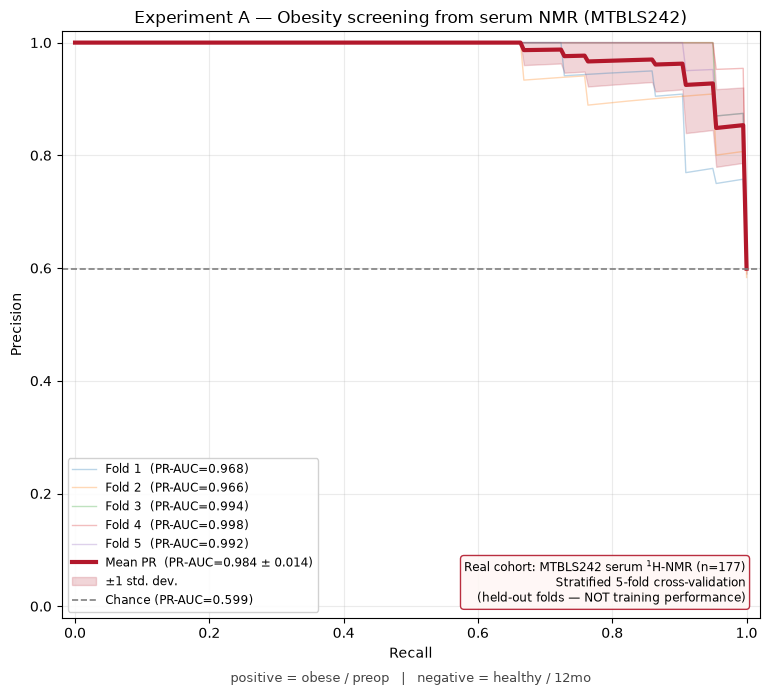

Mean PR-AUC = 0.984 +/- 0.014  (stratified 5-fold CV)


In [3]:
mean_pr_auc, std_pr_auc = plot_cv_pr(
    precisions, pr_aucs, mean_recall,
    title='Experiment A — Obesity screening from serum NMR (MTBLS242)',
    provenance='Real cohort: MTBLS242 serum $^1$H-NMR (n=177)',
    out_png=os.path.join('.', 'expA_obesity_pr.png'),
    pos_label='obese / preop', neg_label='healthy / 12mo')
print(f'Mean PR-AUC = {mean_pr_auc:.3f} +/- {std_pr_auc:.3f}  (stratified 5-fold CV)')

### 3.2 Which metabolites drive the call (SHAP)

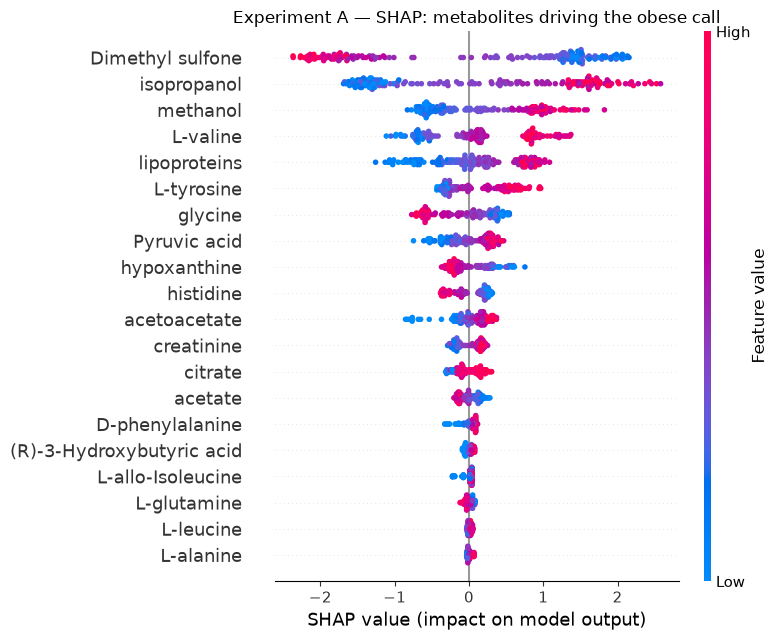

In [4]:
final = XGBClassifier(**XGB).fit(Xdf, y)
sv = shap.TreeExplainer(final).shap_values(Xdf)
shap.summary_plot(sv, Xdf, show=False, plot_size=(8, 6.5))
plt.title('Experiment A — SHAP: metabolites driving the obese call')
plt.tight_layout(); plt.savefig('expA_obesity_shap.png', dpi=150, bbox_inches='tight'); plt.show()

### 3.3 Honest read (⚠ before quoting the 0.97)

1. **Easy contrast.** preop vs 12mo are the cohort *extremes*, so a high AUC is expected. This measures separability of the extremes — not general population screening power.
2. **Exogenous confounders lead SHAP:** `dimethyl sulfone`, `isopropanol`, `methanol` are exogenous/artifactual. **Isopropanol is a surgical skin-prep contaminant** — preop bloods are drawn in a surgical setting, 12-month samples at outpatient follow-up, so part of the separation is *sample context, not metabolism.*
3. **Real biology is present too:** `L-valine` (BCAA — earliest insulin-resistance NMR marker), `lipoproteins`, `L-tyrosine`, `lactate` all shift legitimately with obesity.
4. **Repeated measures.** Patient IDs aren't recoverable from `sample_ids`, so same-patient leakage across folds can't be fully excluded.

**Next step:** re-run dropping the 3 exogenous compounds — if AUC holds, the metabolic signal is real; if it collapses, the 0.97 was largely sample-context artifact.